# Projet 2 - LLM do wykrywania Fake News


### Przygotowanie modelu

In [1]:
# Potrzebne biblioteki
# %pip install openai python-dotenv pandas numpy sentence-transformers faiss-cpu rapidfuzz scikit-learn
# %pip install rapidfuzz -q
# %pip install openai
# %pip install dotenv
# %pip install sentence_transformers
# %pip install faiss-cpu
# %pip install tf-keras

In [2]:
import os

import time

import warnings

# Praca z danymi
import numpy as np
import pandas as pd

# Obsługa LLM
from openai import OpenAI
from dotenv import load_dotenv

# Biblioteki do RAG
from sentence_transformers import SentenceTransformer
import faiss

# Biblioteki do weryfikacji i wizualizacji
from rapidfuzz import fuzz
from IPython.display import display, HTML

# Konfiguracja środowiska
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)

import json
import re

# Wizualizcja zapytana
from IPython.display import display, HTML
import uuid

# Wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns

# Metryki
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [3]:
client = OpenAI(
    base_url="http://192.168.137.18:1234/v1",
    api_key="lm-studio"
)

MODEL_NAME = "local-model" 

# Test Połączenia
try:
    models = client.models.list()
    print(f"Połączono z serwerem\nDostępne modele -> {[m.id for m in models.data]}")

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": "Jesteś pomocnym asystentem."},
            {"role": "user", "content": "Przywitaj się krótko po polsku."}
        ],
        temperature=0.7,
        max_tokens=50
    )
    
    # Zabezpieczenie przed pustą odpowiedzią
    if response and response.choices:
        content = response.choices[0].message.content
        print("Sukces - poniżej odpowiedź modelu:\n")
        print(f"{content}")
    else:
        print("Wykryto połączenie, ale model zwrócił pustą odpowiedź")
        print(response)

except Exception as e:
    print(f"Błąd -> {e}")

Połączono z serwerem
Dostępne modele -> ['openai/gpt-oss-20b', 'text-embedding-nomic-embed-text-v1.5']
Sukces - poniżej odpowiedź modelu:

Cześć!


### Przygotowanie bazy i pytań

In [4]:
# Baza

knowledge_base_texts = [
    # Gospodarka
    "Według GUS stopa bezrobocia rejestrowanego w Polsce w styczniu 2024 wyniosła 5,4%.",
    "Minimalne wynagrodzenie w Polsce od 1 stycznia 2024 wynosi 4242 zł brutto, a od lipca 4300 zł.",
    "Inflacja to proces wzrostu przeciętnego poziomu cen w gospodarce.",
    "Oficjalną walutą w Polsce jest Polski Złoty (PLN), a nie Euro.",
    "Dług publiczny Polski (EDP) na koniec 2023 r. wyniósł około 1,7 bln zł.",

    # Polityka/Historia
    "Polska stała się członkiem Unii Europejskiej 1 maja 2004 roku.",
    "Obecnym prezydentem Polski jest Andrzej Duda, a premierem Donald Tusk (stan na 2024).",
    "Stolicą Polski jest Warszawa, która jest największym miastem w kraju.",
    "Stolicą Niemiec jest Berlin.",
    "Bitwa pod Grunwaldem, jedna z największych bitew średniowiecznej Europy, odbyła się w 1410 roku.",
    "Pierwszym historycznym władcą i królem Polski był Bolesław Chrobry (koronowany w 1025).",
    "Unia Europejska nie posiada kompetencji do zakazywania upraw w ogródkach przydomowych.",
    "Parlament Europejski przyjął dyrektywę budynkową dążącą do zeroemisyjności od 2030 roku.",

    # Sport
    "Usain Bolt jest rekordzistą świata w biegu na 100m i 200m, uważanym za najszybszego człowieka.",
    "Złoty medal olimpijski składa się w ponad 90% ze srebra i jest tylko pokryty warstwą złota (min. 6g).",
    "Reprezentacja Portugalii wygrała Mistrzostwa Europy w Piłce Nożnej (Euro) w 2016 roku, pokonując Francję.",
    "Partia szachów może trwać teoretycznie nawet kilka tysięcy ruchów (zasada 50 ruchów ogranicza to w praktyce).",
    "Real Madryt jest rekordzistą pod względem liczby wygranych w Lidze Mistrzów (ponad 14 razy).",
    "Letnie Igrzyska Olimpijskie odbywają się co 4 lata.",
    "Piłka nożna jest najpopularniejszym sportem na świecie pod względem liczby fanów.",
    "Adam Małysz to były wybitny skoczek narciarski, zdobywca medali olimpijskich i Kryształowych Kul.",
    "Karolina Gralak to postać fikcyjna w kontekście rekordów świata w sprincie.",
    "Robert Lewandowski jest kapitanem reprezentacji Polski w piłce nożnej.",

    # Yt/Technologia
    "MrBeast (Jimmy Donaldson) posiada kanał na YouTube z największą liczbą subskrypcji wśród twórców indywidualnych.",
    "Pierwszym filmem opublikowanym na YouTube był „Me at the zoo” wrzucony przez Jaweda Karima.",
    "Python to język programowania wysokiego poziomu, popularny w Data Science i AI.",
    "Wiedźmin 3: Dziki Gon to gra RPG wyprodukowana przez polskie studio CD Projekt RED.",
    "Samochody elektryczne nie emitują spalin podczas jazdy, ale ich produkcja obciąża środowisko.",

    # Nauka/zdrowie
    "Szczepionki mRNA nie integrują się z jądrem komórkowym i nie zmieniają ludzkiego DNA.",
    "Globalne ocieplenie jest faktem naukowym potwierdzonym przez konsensus klimatologów.",
    "Sieć 5G wykorzystuje fale radiowe niejonizujące, które nie uszkadzają DNA.",
    "Ziemia krąży wokół Słońca (teoria heliocentryczna) i jest geoidą (nie jest płaska).",
    "Woda wrze w temperaturze 100 stopni Celsjusza przy ciśnieniu 1 atmosfery.",
    "Palenie tytoniu jest główną przyczyną raka płuc.",
    "Antybiotyki działają na bakterie, a nie na wirusy (takie jak grypa czy COVID).",

    # Jedzenie/Inne
    "Marchew jest bogata w beta-karoten, który organizm przekształca w witaminę A.",
    "Ciemna czekolada (o wysokiej zawartości kakao) zawiera przeciwutleniacze korzystne dla serca.",
    "Jajka są źródłem pełnowartościowego białka, witamin (A, D, B12) i choliny.",
    "Spożywanie cukru w nadmiarze prowadzi do otyłości i cukrzycy, ale cukier sam w sobie nie jest trucizną.",
    "Delfiny to ssaki wodne, a nie ryby."
]

print(f"Baza wiedzy załadowana -> {len(knowledge_base_texts)} dokumentów")


# Zapytania

data_samples = [
    # Prawda:
    # Gospodarka
    {"claim": "Bezrobocie w Polsce wynosi około 5,4%.", "label": "Prawda", "category": "Gospodarka"},
    {"claim": "Minimalna krajowa to teraz ponad 4200 złotych.", "label": "Prawda", "category": "Gospodarka"},
    {"claim": "Inflacja to proces wzrostu przeciętnego poziomu cen w gospodarce.", "label": "Prawda", "category": "Gospodarka"},
    
    # Polityka / Historia
    {"claim": "Polska weszła do Unii Europejskiej w 2004 roku.", "label": "Prawda", "category": "Polityka"},
    {"claim": "Stolicą Polski jest Warszawa.", "label": "Prawda", "category": "Geografia"},
    {"claim": "Bitwa pod Grunwaldem odbyła się w 1410 roku.", "label": "Prawda", "category": "Historia"},
    {"claim": "Pierwszym królem Polski był Bolesław Chrobry.", "label": "Prawda", "category": "Historia"},
    
    # Sport
    {"claim": "Usain Bolt najszybciej biega.", "label": "Prawda", "category": "Sport"},
    {"claim": "Głównym budulcem złotego medalu olimpijskiego jest srebro.", "label": "Prawda", "category": "Sport"},
    {"claim": "Portugalia wygrała Mistrzostwa Europy w Piłce Nożnej w 2016 roku.", "label": "Prawda", "category": "Sport"},
    {"claim": "Najdłuższa możliwa partia szachów może trwać kilka tysięcy ruchów.", "label": "Prawda", "category": "Sport"},
    {"claim": "Real Madryt wygrał Ligę Mistrzów 15 razy, co jest rekordem.", "label": "Prawda", "category": "Sport"},
    {"claim": "Portugalia wygrała finał Mistrzostw Europy 2016 z Francją.", "label": "Prawda", "category": "Sport"},
    {"claim": "Usain Bolt zdobył złote medale olimpijskie na dystansach 100 m i 200 m.", "label": "Prawda", "category": "Sport"},
    {"claim": "Złote medale olimpijskie zawierają tylko niewielką ilość czystego złota.", "label": "Prawda", "category": "Sport"},
    {"claim": "Igrzyska olimpijskie odbywają się co cztery lata.", "label": "Prawda", "category": "Sport"},
    {"claim": "Piłka nożna jest najpopularniejszym sportem na świecie.", "label": "Prawda", "category": "Sport"},
    {"claim": "Karolina Gralak nie jest najszybszym człowiekiem, bo ma złamaną nogę.", "label": "Prawda", "category": "Sport"},
    {"claim": "Adam Małysz to były skoczek narciarski, a obecnie prezes PZN.", "label": "Prawda", "category": "Sport"},

    # YouTube / Tech / Kultura
    {"claim": "Największym kanałem na YouTubie pod względem liczby subskrypcji jest MrBeast.", "label": "Prawda", "category": "YouTube"},
    {"claim": "Pierwszym filmem opublikowanym na YouTubie był „Me at the zoo”.", "label": "Prawda", "category": "YouTube"},
    {"claim": "Python to popularny język programowania.", "label": "Prawda", "category": "Tech"},
    {"claim": "Wiedźmin 3 to gra wyprodukowana przez polskie studio CD Projekt RED.", "label": "Prawda", "category": "Gry"},

    # Nauka / Zdrowie / Jedzenie
    {"claim": "Marchew zawiera beta-karoten, który wspiera prawidłowe widzenie.", "label": "Prawda", "category": "Jedzenie"},
    {"claim": "Ciemna czekolada może mieć korzystny wpływ na układ krążenia.", "label": "Prawda", "category": "Jedzenie"},
    {"claim": "Jajka są dobrym źródłem białka i witamin.", "label": "Prawda", "category": "Jedzenie"},
    {"claim": "Ziemia krąży wokół Słońca.", "label": "Prawda", "category": "Nauka"},
    {"claim": "Woda wrze w temperaturze 100 stopni Celsjusza przy normalnym ciśnieniu.", "label": "Prawda", "category": "Nauka"},
    {"claim": "Palenie papierosów zwiększa ryzyko zachorowania na raka płuc.", "label": "Prawda", "category": "Zdrowie"},

    # Fałsz:
    # Gospodarka / Polityka
    {"claim": "Bezrobocie w Polsce wynosi obecnie 20%, rząd ukrywa dane.", "label": "Fałsz", "category": "Gospodarka"},
    {"claim": "Polska wyszła z Unii Europejskiej w zeszłym roku.", "label": "Fałsz", "category": "Polityka"},
    {"claim": "Oficjalną walutą w Polsce jest Euro.", "label": "Fałsz", "category": "Gospodarka"},
    {"claim": "Stolicą Niemiec jest Monachium.", "label": "Fałsz", "category": "Geografia"},
    {"claim": "Władysław Jagiełło wynalazł internet.", "label": "Fałsz", "category": "Historia"},

    # Nauka / Zdrowie / Tech
    {"claim": "Szczepionki zmieniają DNA ludzi i robią z nich mutanty.", "label": "Fałsz", "category": "Zdrowie"},
    {"claim": "Sieć 5G służy do sterowania umysłami poprzez mikrofale.", "label": "Fałsz", "category": "Nauka"},
    {"claim": "Ziemia jest płaska i otoczona murem lodowym.", "label": "Fałsz", "category": "Nauka"},
    {"claim": "Ludzie wykorzystują tylko 10% swojego mózgu.", "label": "Fałsz", "category": "Nauka"},
    {"claim": "Słońce krąży wokół Ziemi.", "label": "Fałsz", "category": "Nauka"},
    {"claim": "Antybiotyki zabijają wirusy, takie jak grypa.", "label": "Fałsz", "category": "Zdrowie"},

    # Sport
    {"claim": "Karolina Gralak jest najszybszym człowiekiem na świecie.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Polska wygrała mistrzostwa Europy w 2016.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Złoty medal olimpijski jest wykonany tylko ze złota.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Portugalia wygrała Mistrzostwa Europy w Piłce Nożnej w 2012 roku.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Partia szachów nie może trwać dłużej niż 200 ruchów.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Real Madryt nigdy nie wygrał Ligi Mistrzów więcej niż 5 razy.", "label": "Fałsz", "category": "Sport"},
    {"claim": "FC Barcelona wygrała Ligę Mistrzów najwięcej razy.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Portugalia przegrała finał Mistrzostw Europy 2016 z Francją.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Igrzyska olimpijskie odbywają się co roku.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Koszykówka jest popularniejsza globalnie niż piłka nożna.", "label": "Fałsz", "category": "Sport"},
    {"claim": "Robert Lewandowski gra w reprezentacji Hiszpanii.", "label": "Fałsz", "category": "Sport"},

    # YouTube / Inne
    {"claim": "Największym kanałem na YouTubie pod względem subskrypcji jest Friz.", "label": "Fałsz", "category": "YouTube"},
    {"claim": "Pierwszym filmem na YouTubie był teledysk muzyczny.", "label": "Fałsz", "category": "YouTube"},
    {"claim": "Jedzenie marchwi znacząco pogarsza wzrok.", "label": "Fałsz", "category": "Jedzenie"},
    {"claim": "Czekolada zawsze szkodzi zdrowiu i nie ma żadnych wartości odżywczych.", "label": "Fałsz", "category": "Jedzenie"},
    {"claim": "Jajka nie zawierają żadnych wartościowych składników odżywczych.", "label": "Fałsz", "category": "Jedzenie"},
    {"claim": "Delfiny są rybami.", "label": "Fałsz", "category": "Przyroda"},

    # MANIPULACJA 
    {"claim": "Inflacja szaleje, ceny rosną o 20% miesięcznie.", "label": "Manipulacja", "category": "Gospodarka"},
    {"claim": "Unia Europejska chce zakazać sadzenia marchewki w Polsce.", "label": "Manipulacja", "category": "Polityka"},
    {"claim": "Jedzenie dużych ilości marchwi daje nadludzki wzrok.", "label": "Manipulacja", "category": "Jedzenie"},
    {"claim": "Samochody elektryczne trują środowisko bardziej niż stare diesle.", "label": "Manipulacja", "category": "Tech"},
    {"claim": "Wszyscy politycy to złodzieje.", "label": "Manipulacja", "category": "Polityka"},
    {"claim": "Gry komputerowe powodują tylko agresję u dzieci.", "label": "Manipulacja", "category": "Psychologia"},
    {"claim": "Cukier to biała śmierć, która zabija natychmiast po spożyciu.", "label": "Manipulacja", "category": "Zdrowie"},

    # NIEWERYFIKOWALNE 
    {"claim": "Jutro w Warszawie będzie padać grad wielkości piłek do tenisa.", "label": "Nieweryfikowalne", "category": "Pogoda"},
    {"claim": "Premier planuje tajną wizytę na Marsie w 2030 roku.", "label": "Nieweryfikowalne", "category": "Polityka"},
    {"claim": "Bóg stworzył świat w dokładnie 7 dni.", "label": "Nieweryfikowalne", "category": "Religia"},
    {"claim": "To jest najsmaczniejsza pizza na świecie.", "label": "Nieweryfikowalne", "category": "Opinia"},
    {"claim": "W roku 2100 ludzie będą żyć średnio 150 lat.", "label": "Nieweryfikowalne", "category": "Przyszłość"},
    {"claim": "Obca cywilizacja obserwuje nas z innej galaktyki.", "label": "Nieweryfikowalne", "category": "Kosmos"},
    {"claim": "Wygram jutro w totolotka.", "label": "Nieweryfikowalne", "category": "Przyszłość"}
]

# Konwersja do DataFrame
df_test = pd.DataFrame(data_samples)

print(f"Zbiór testowy załadowany -> {len(df_test)} przykładów")

Baza wiedzy załadowana -> 40 dokumentów
Zbiór testowy załadowany -> 71 przykładów


### Funkcje pomocnicze

In [5]:
def get_kb_context():
    return "\n".join([f"- {fact}" for fact in knowledge_base_texts])

In [6]:
def _extract_json_object(text: str):
    """Odporne parsowanie: jeśli model dopisał tekst przed/po JSON, wycinamy pierwszy blok {...} i parsujemy"""
    text = text.strip()

    # 1) spróbuj wprost
    try:
        return json.loads(text)
    except Exception:
        pass

    # 2) usuń markdown
    if "```json" in text:
        text = text.split("```json", 1)[1].split("```", 1)[0].strip()
    elif "```" in text:
        parts = text.split("```")
        if len(parts) >= 2:
            text = parts[1].strip()

    # 3) wytnij pierwszy obiekt
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not m:
        raise ValueError("Nie znaleziono obiektu JSON w odpowiedzi modelu")
    return json.loads(m.group(0))

In [7]:
def retrieve_evidence(query, k=5):
    """Pobieranie dowodów - DDGS"""
    results = []
    try:
        from ddgs import DDGS
        with DDGS() as ddgs:
            search_gen = ddgs.text(query, region='pl-pl', max_results=k)
            if search_gen:
                for res in list(search_gen):
                    title = str(res.get('title', 'Bez tytułu'))
                    body = str(res.get('body', res.get('snippet', '')))
                    results.append(f"{title}: {body}")
    except Exception as e:
        print(f"Błąd DDGS -> {e}")
        results.append(f"Błąd wyszukiwania: {str(e)}")

    if not results:
        results.append("Brak wyników w internecie")
    return results

In [8]:
def verify_grounding(citations, evidence_list):
    """Sprawdzanie czy cytaty są w tekstach - XAI"""
    if not citations:
        return 0.0, []

    valid = []
    score_sum = 0

    for cit in citations:
        if isinstance(cit, dict):
            cit = str(cit.get('text', cit.get('quote', str(cit))))
        cit_text = str(cit).lower()

        best = 0
        for ev in evidence_list:
            if isinstance(ev, dict):
                ev = str(ev.get('body', str(ev)))
            ev_text = str(ev).lower()

            score = fuzz.partial_ratio(cit_text, ev_text)
            if score > best:
                best = score

        if best > 75:
            valid.append(cit)
            score_sum += 1

    return (score_sum / len(citations)) * 100, valid

In [9]:
def get_completion(prompt, system_role="Jesteś asystentem."):
    """
    - wszystko wysyłamy jako 'user'
    - twardo prosimy o JSON i tylko JSON
    - parsujemy odporne: _extract_json_object()
    """
    try:
        full_prompt = f"""
ROLA(instrukcja):
{system_role}

WYMAGANIA:
- Zwróć WYŁĄCZNIE poprawny JSON (jeden obiekt)
- Nie dodawaj żadnego tekstu przed ani po JSON
- Nie używaj markdown (żadnych ```)

ZADANIE:
{prompt}
""".strip()

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[{"role": "user", "content": full_prompt}],
            temperature=0.0,
            max_tokens=700
        )

        content = response.choices[0].message.content
        return _extract_json_object(content)

    except Exception as e:
        print(f"Błąd modelu / JSON: {e}")
        return {
            "is_claim": True,
            "final_verdict": "Błąd",
            "final_reasoning": "Model nie zwrócił poprawnego JSON.",
            "polish_summary": "Wystąpił błąd techniczny.",
            "key_quotes": [],
            "confidence": 0
        }


In [10]:
def validate_intent(claim):
    """Sprawdzamy czy to na pewno pytanie"""
    prompt = f"""
Czy tekst: "{claim}" to zdanie oznajmujące lub pytanie weryfikujące (np. "Czy X to Y?")?
Odpisz JSON: {{"is_claim": true}} lub {{"is_claim": false, "refusal_reason": "..."}}
"""
    return get_completion(prompt, "Klasyfikator intencji.")

In [23]:
# Główna logika

def verify_claim_complete(claim, bypass_guardrail=False, manual_label=None):
    """ Główna logika modelu:
    claim -> zapytanie
    bypass_guardrail -> czy moze wejść coś innego niz tylko pytanie
    manual_label -> Odowiedz prawdziwa(służy potem do sprawdzenia popraności)"""
    # 1) Guardrail
    if not bypass_guardrail:
        val = validate_intent(claim)
        if val.get('is_claim') is False:
            return {
                "final_verdict": "Odrzucono",
                "polish_summary": val.get('refusal_reason', "To nie jest poprawne zapytanie o FakeNews"),
                "final_reasoning": "Odrzucono przez filtr intencji",
                "confidence": 0,
                "evidence_used": [],
                "grounding_score": 0,
                "manual_label": manual_label
            }
    else:
        print("Pominięto część sprawdzającą czy to poprawne zapytanie")

    # 2) Retrieval
    evidence = retrieve_evidence(claim)
    ev_text = "\n".join([f"- {str(i)}" for i in evidence])

    # 3) Draft
    kb_context = get_kb_context()

    prompt_draft = f"""
    MASZ PONIŻSZĄ BAZĘ WIEDZY (FAKTY):

    {kb_context}

    TWIERDZENIE DO OCENY:
    "{claim}"

    Na podstawie POWYŻSZYCH FAKTÓW oceń twierdzenie.

    ZWRÓĆ TYLKO JSON:
    {{"draft_verdict": "Prawda/Fałsz/Manipulacja/Nieweryfikowalne", "draft_reasoning": "..."}}
    """

    draft = get_completion(prompt_draft, "Robisz wstępną ocenę twierdzenia.")


    # 4) Critique
    prompt_critique = f"""
Twierdzenie: "{claim}"
Wstępny werdykt: {draft.get('draft_verdict')}
Wstępne uzasadnienie: {draft.get('draft_reasoning')}

Dowody:
{ev_text}

ZASADY OCENY:
- Prawda: Fakty potwierdzone w dowodach.
- Fałsz: Fakty stojące w sprzeczności z dowodami.
- Manipulacja: Używa prawdziwych danych/zdarzeń, ale wyciąga z nich fałszywe, przesadzone lub emocjonalne wnioski (półprawda).
- Nieweryfikowalne: Dotyczy przyszłości, opinii (co jest "najlepsze"), lub prywatnych zdarzeń, o których nie ma informacji w sieci.

Zwróć dokładnie JSON:
{{
  "final_verdict": "Prawda" | "Fałsz" | "Manipulacja" | "Nieweryfikowalne",
  "final_reasoning": "...",
  "polish_summary": "...",
  "key_quotes": ["cytat1", "cytat2"],
  "confidence": 0-100
}}
"""
    final = get_completion(prompt_critique, "Jesteś dokładnym fact-checkerem.")


    # 5) Grounding
    quotes = final.get('key_quotes', [])
    if not isinstance(quotes, list):
        quotes = []
 
    g_score, valid_q = verify_grounding(quotes, evidence)

    final['evidence_used'] = evidence
    final['draft_logic'] = draft
    final['grounding_score'] = g_score
    final['valid_quotes'] = valid_q
    final['manual_label'] = manual_label

    return final

### Wizualizcja zapytań i odpowiedzi

In [12]:
def display_premium_result(claim, result):
    """Ładne wyśwetlanie z użyciem HTML"""

    if not result or not isinstance(result, dict):
        result = {"final_verdict": "Błąd", "polish_summary": "Błąd danych."}

    # Pobieranie danych
    verdict = str(result.get('final_verdict', 'Błąd'))
    polish_summary = str(result.get('polish_summary') or "Brak podsumowania.")
    final_reasoning = str(result.get('final_reasoning', '...'))
    
    # Obsługa Draftu
    draft_data = result.get('draft_logic', {})
    draft_text = str(draft_data.get('draft_reasoning', '...')) if isinstance(draft_data, dict) else "..."

    # Logika z ręczna etykietą
    manual_label = result.get('manual_label')
    manual_check_html = ""
    
    if manual_label:
        # Normalizacja do porównania (ignorujemy wielkość liter)
        v_clean = verdict.lower().strip()
        m_clean = str(manual_label).lower().strip()
        
        if v_clean == m_clean:
            # SUKCES
            manual_check_html = f"""
            <div style="background: #dcfce7; color: #166534; padding: 10px 20px; font-weight: bold; border-bottom: 1px solid #bbf7d0; display: flex; align-items: center; gap: 10px;">
                <span>🎯 BRAWO!</span>
                <span style="font-weight: normal;">Model zgodny z Twoją oceną: <strong>{manual_label.upper()}</strong></span>
            </div>
            """
        else:
            # PORAŻKA
            manual_check_html = f"""
            <div style="background: #fee2e2; color: #991b1b; padding: 10px 20px; font-weight: bold; border-bottom: 1px solid #fecaca; display: flex; align-items: center; gap: 10px;">
                <span>⚠️ BŁĄD MODELU!</span>
                <span style="font-weight: normal;">Ty twierdzisz: <strong>{manual_label.upper()}</strong>, a model: <strong>{verdict.upper()}</strong></span>
            </div>
            """

    # Kolory
    theme = {
        "Prawda": {"bg": "#f0fdf4", "border": "#22c55e", "icon": "✅", "header": "linear-gradient(135deg, #16a34a 0%, #15803d 100%)", "shadow": "rgba(22, 163, 74, 0.2)"},
        "Fałsz": {"bg": "#fef2f2", "border": "#ef4444", "icon": "❌", "header": "linear-gradient(135deg, #dc2626 0%, #b91c1c 100%)", "shadow": "rgba(220, 38, 38, 0.2)"},
        "Manipulacja": {"bg": "#fffbeb", "border": "#f59e0b", "icon": "⚠️", "header": "linear-gradient(135deg, #d97706 0%, #b45309 100%)", "shadow": "rgba(217, 119, 6, 0.2)"},
        "Nieweryfikowalne": {"bg": "#f8fafc", "border": "#64748b", "icon": "❓", "header": "linear-gradient(135deg, #475569 0%, #334155 100%)", "shadow": "rgba(71, 85, 105, 0.2)"},
        "Odrzucono": {"bg": "#f3f4f6", "border": "#6366f1", "icon": "⛔", "header": "linear-gradient(135deg, #6366f1 0%, #4338ca 100%)", "shadow": "rgba(99, 102, 241, 0.2)"},
        "Błąd": {"bg": "#fff", "border": "#000", "icon": "☠️", "header": "#333", "shadow": "rgba(0,0,0,0.1)"}
    }
    
    style = theme.get(verdict, theme["Nieweryfikowalne"])
    is_rejected = (verdict == "Odrzucono")
    
    # Grounding Score
    g_score = result.get('grounding_score', 0)
    if not isinstance(g_score, (int, float)): g_score = 0
    g_color = "#22c55e" if g_score > 80 else ("#eab308" if g_score > 50 else "#ef4444")

    # HTML
    html = f"""
    <div style="font-family: 'Segoe UI', sans-serif; background: #fff; border-radius: 16px; box-shadow: 0 10px 15px -3px {style['shadow']}; border: 1px solid #e2e8f0; max-width: 850px; margin-bottom: 40px; overflow: hidden;">
        
        <div style="background: {style['header']}; color: white; padding: 18px 25px; display: flex; justify-content: space-between; align-items: center;">
            <span style="font-weight: 600; letter-spacing: 0.5px;">AI FACT-CHECKER</span>
            <span style="background: rgba(255,255,255,0.2); padding: 6px 14px; border-radius: 30px; font-weight: 700; font-size: 0.9em;">{style['icon']} {verdict.upper()}</span>
        </div>
        
        {manual_check_html} <div style="padding: 25px; color: #334155;">
            <div style="font-size: 0.8em; text-transform: uppercase; color: #94a3b8; font-weight: 700; margin-bottom: 5px;">ANALIZOWANE WEJŚCIE</div>
            <div style="font-size: 1.3em; font-weight: 800; margin-bottom: 20px; color: #0f172a; border-left: 5px solid {style['border']}; padding-left: 15px;">"{claim}"</div>

            {'<div style="background:#eff6ff; border:1px solid #3b82f6; padding:15px; border-radius:8px; color:#1e40af;">⚠️ ' + polish_summary + '</div>' if is_rejected else ''}
    """
    
    if not is_rejected:
        html += f"""
            <div style="display:flex; gap:10px; margin-bottom:15px;">
                <div style="flex:1; background:#f8fafc; padding:10px; border-radius:8px; border:1px solid #e2e8f0; font-size:0.9em; color:#64748b;">
                    <strong>1. Wstępna analiza:</strong> {draft_text}
                </div>
                <div style="flex:1; background:{style['bg']}; padding:10px; border-radius:8px; border:1px solid {style['border']}; font-size:0.9em; color:{style.get('text', '#0f172a')};">
                    <strong>2. Werdykt po krytyce:</strong> {final_reasoning}
                </div>
            </div>

            <div style="margin-bottom: 20px; font-size: 0.85em; display: flex; align-items: center; gap: 10px;">
                <strong>Wiarygodność Cytowań (XAI):</strong>
                <div style="flex-grow: 1; background: #e2e8f0; height: 8px; border-radius: 4px; overflow: hidden;">
                    <div style="width: {g_score}%; background: {g_color}; height: 100%;"></div>
                </div>
                <span style="color: {g_color}; font-weight: bold;">{g_score:.0f}%</span>
            </div>

            <div style="background: linear-gradient(to right, #f8fafc, #fff); border-left: 4px solid #0f172a; padding: 15px; border-radius: 4px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
                <div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
                    <span>🇵🇱</span><strong style="color:#0f172a;">PODSUMOWANIE</strong>
                </div>
                <p style="margin:0; color:#334155;">{polish_summary}</p>
            </div>
            
            <div style="margin-top:20px; font-size:0.8em; font-weight:700; color:#94a3b8; text-transform:uppercase;">DOWODY (LIVE SEARCH):</div>
            <ul style="padding-left:0; list-style:none; margin-top:10px;">
        """
        evidence = result.get('evidence_used', [])
        if isinstance(evidence, list):
            for item in evidence:
                clean = str(item)[:200] + "..."
                html += f'<li style="background:#fff; border:1px solid #e2e8f0; padding:8px 12px; border-radius:6px; font-size:0.85em; color:#475569; margin-bottom:5px;">{clean}</li>'
        html += "</ul>"

    html += "</div></div>"
    display(HTML(html))

### Przykładowe wywołania dla testu

In [13]:
claim2 = "2 + 2 = 4"
display_premium_result(claim2, verify_claim_complete(claim2))

In [14]:
claim3 = "Karolina Gralak jest najszybszym człowiekiem na świecie."
display_premium_result(claim3, verify_claim_complete(claim3))

In [15]:
claim4 = 'Portugalia wygrała mistrzostwa Europy w 2016'
display_premium_result(claim4, verify_claim_complete(claim4))

In [16]:
claim5 = 'Ile waży Słońce?'
display_premium_result(claim5, verify_claim_complete(claim5))

In [17]:
claim6 = 'Opowiedz mi żart o programistach.'
display_premium_result(claim6, verify_claim_complete(claim6, bypass_guardrail=True))

Pominięto część sprawdzającą czy to poprawne zapytanie


Do tej pory nasz model pokazał tylko podstawowowe przyporządkowanie sprawdzimy czy moze teraz mu sie uda dobrze dopsaowac

In [24]:
hard_cases = [
    # MANIPULACJA
    "Unia Europejska nakazała konfiskatę wszystkich samochodów spalinowych w Polsce do końca tego roku, bo wszedł zakaz na takowe pokjazdy",
    "Woda z kranu w Polsce zawiera chlor, który jest gazem bojowym, dlatego picie jej jest śmiertelne.",
    
    # NIEWERYFIKOWALNE
    "W 2040 roku prezydentem Polski zostanie kobieta o imieniu Anna.",
    "Zupa pomidorowa jest obiektywnie najsmaczniejszą zupą na świecie."
]

for claim in hard_cases:
    result = verify_claim_complete(claim, bypass_guardrail=True)
    display_premium_result(claim, result)

--- ROZPOCZYNAM TESTY STRESOWE (EDGE CASES) ---
Pominięto część sprawdzającą czy to poprawne zapytanie


Pominięto część sprawdzającą czy to poprawne zapytanie


Pominięto część sprawdzającą czy to poprawne zapytanie


Pominięto część sprawdzającą czy to poprawne zapytanie


### Wyniki dla zapytań - metryki

In [18]:
# Upewnij się, że df_test istnieje
if 'df_test' not in locals():
    # gdyby nie istaniały to szybka podmianka
    df_test = pd.DataFrame([
        {"claim": "Polska jest w UE.", "label": "Prawda"},
        {"claim": "Ziemia jest płaska.", "label": "Fałsz"},
        {"claim": "Inflacja to 50%.", "label": "Fałsz"},
        {"claim": "Stolicą Polski jest Warszawa.", "label": "Prawda"}
    ])

In [19]:
# funkcje pomocnicze

def evaluate_baseline(df):
    """Testuje 'goły' model (bez internetu)"""
    print("📉 Testowanie modelu BASELINE (Zero-shot)...")
    preds = []
    for i, row in df.iterrows():
        try:
            prompt = f"Oceń czy to Prawda czy Fałsz: '{row['claim']}'. Odpisz jednym słowem."
            response = client.chat.completions.create(
                model=MODEL_NAME, messages=[{"role": "user", "content": prompt}], temperature=0.0
            )
            ans = response.choices[0].message.content.strip().lower()
            if "prawda" in ans or "true" in ans: preds.append("Prawda")
            elif "fałsz" in ans or "false" in ans: preds.append("Fałsz")
            else: preds.append("Nieweryfikowalne")
        except: preds.append("Błąd")
    return preds

In [20]:
def evaluate_system(df):
    """Testuje nasz pełny system (RAG)"""
    print("🚀 Testowanie TWOJEGO SYSTEMU (RAG)...")
    preds = []
    g_scores = []
    for i, row in df.iterrows():
        print(f"   [{i+1}/{len(df)}] {row['claim'][:40]}...")
        try:
            res = verify_claim_complete(row['claim'])
            verdict = str(res.get('final_verdict', 'Błąd')).strip().capitalize()
            # Normalizacja specyficznych przypadków
            if "prawda" in verdict.lower(): verdict = "Prawda"
            elif "fałsz" in verdict.lower(): verdict = "Fałsz"
            
            preds.append(verdict)
            g_scores.append(res.get('grounding_score', 0))
        except:
            preds.append("Błąd")
            g_scores.append(0)
    return preds, g_scores

📉 Testowanie modelu BASELINE (Zero-shot)...
🚀 Testowanie TWOJEGO SYSTEMU (RAG)...
   [1/71] Bezrobocie w Polsce wynosi około 5,4%....
   [2/71] Minimalna krajowa to teraz ponad 4200 zł...
   [3/71] Inflacja to proces wzrostu przeciętnego ...
   [4/71] Polska weszła do Unii Europejskiej w 200...
   [5/71] Stolicą Polski jest Warszawa....
   [6/71] Bitwa pod Grunwaldem odbyła się w 1410 r...
   [7/71] Pierwszym królem Polski był Bolesław Chr...
   [8/71] Usain Bolt najszybciej biega....
   [9/71] Głównym budulcem złotego medalu olimpijs...
   [10/71] Portugalia wygrała Mistrzostwa Europy w ...
   [11/71] Najdłuższa możliwa partia szachów może t...
   [12/71] Real Madryt wygrał Ligę Mistrzów 15 razy...
   [13/71] Portugalia wygrała finał Mistrzostw Euro...
   [14/71] Usain Bolt zdobył złote medale olimpijsk...
   [15/71] Złote medale olimpijskie zawierają tylko...
   [16/71] Igrzyska olimpijskie odbywają się co czt...
   [17/71] Piłka nożna jest najpopularniejszym spor...
   [18/71] Karol

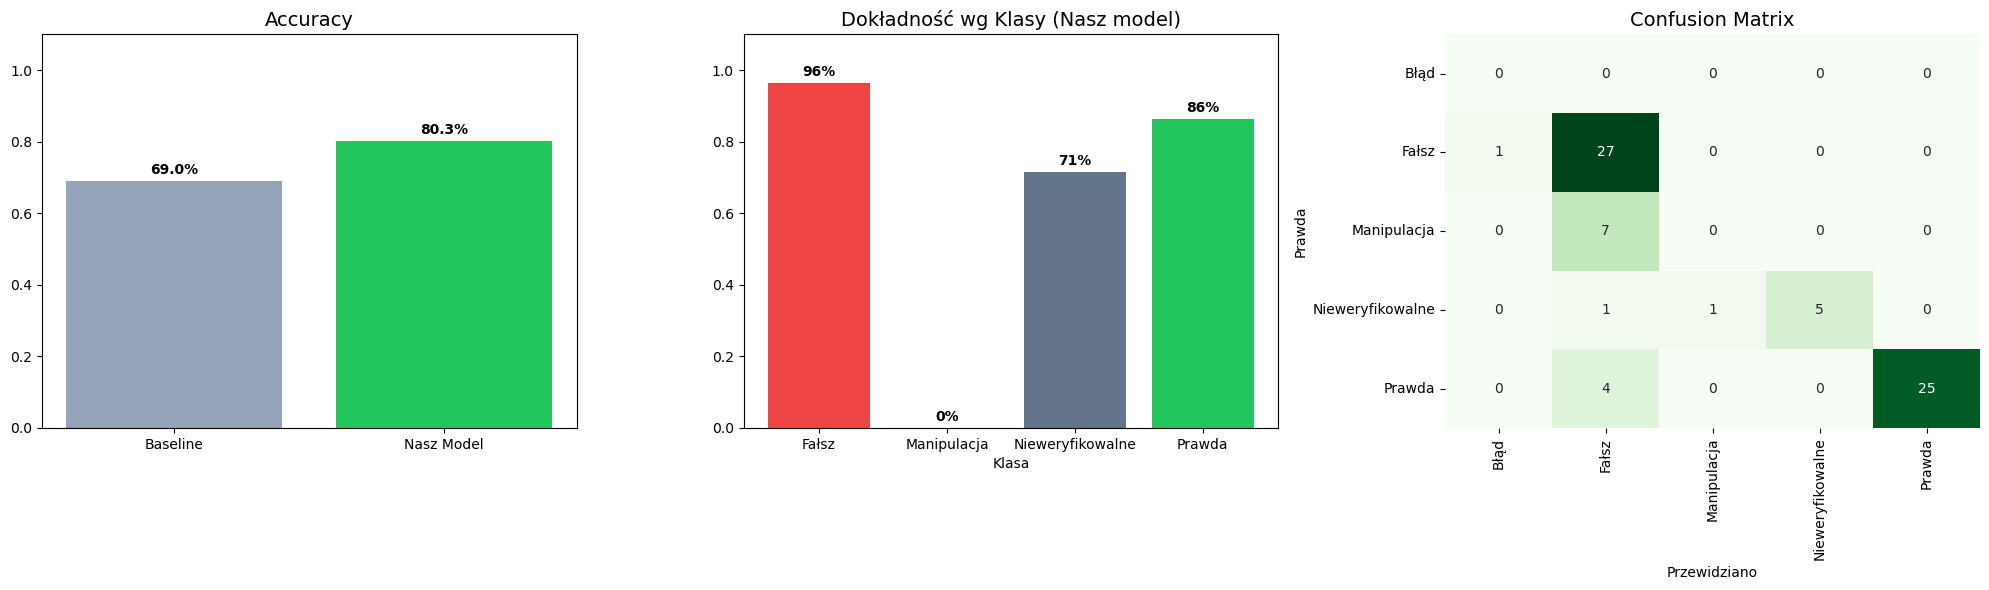

Raport metryk: 

                  precision    recall  f1-score   support

            Błąd       0.00      0.00      0.00         0
           Fałsz       0.69      0.96      0.81        28
     Manipulacja       0.00      0.00      0.00         7
Nieweryfikowalne       1.00      0.71      0.83         7
          Prawda       1.00      0.86      0.93        29

        accuracy                           0.80        71
       macro avg       0.54      0.51      0.51        71
    weighted avg       0.78      0.80      0.78        71

Średnie XAI: 78.9%


In [21]:
# główna pętla
# 1) Wybór danych 
df_eval = df_test

# 2) Uruchomienie testów
start_b = time.time()
y_pred_base = evaluate_baseline(df_eval)

start_s = time.time()
y_pred_sys, grounding_scores = evaluate_system(df_eval)

# Normalizacja etykiet
y_true = [str(x).strip().capitalize() for x in df_eval['label']]

# Wyniki:

# 1) Accuracy
acc_base = accuracy_score(y_true, y_pred_base)
acc_sys = accuracy_score(y_true, y_pred_sys)

print(f"Wyniki ogólne:\n- Model bazowy: {acc_base:.1%}\n- Nasz model: {acc_sys:.1%}")

# Ustawienia wykresów:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Ogólne porównanie na wykresie
axes[0].bar(['Baseline', 'Nasz Model'], [acc_base, acc_sys], color=['#94a3b8', '#22c55e'])
axes[0].set_title('Accuracy', fontsize=14)
axes[0].set_ylim(0, 1.1)
for i, v in enumerate([acc_base, acc_sys]): 
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')

# Dokładność w podziale na klasy(prawda, fałsz, itd)
labels = sorted(list(set(y_true)))
class_acc = []
for label in labels:
    indices = [i for i, x in enumerate(y_true) if x == label]
    if not indices:
        class_acc.append(0)
        continue
    correct = sum([1 for i in indices if y_pred_sys[i] == y_true[i]])
    total = len(indices)
    class_acc.append(correct / total)

colors_map = {'Prawda': '#22c55e', 'Fałsz': '#ef4444', 'Manipulacja': '#eab308', 'Nieweryfikowalne': '#64748b'}
bar_colors = [colors_map.get(l, '#3b82f6') for l in labels]

bars = axes[1].bar(labels, class_acc, color=bar_colors)
axes[1].set_title('Dokładność wg Klasy (Nasz model)', fontsize=14)
axes[1].set_ylim(0, 1.1)
axes[1].set_xlabel('Klasa')

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.0%}", ha='center', fontweight='bold')

# Confusion matrix
try:
    all_labels = sorted(list(set(y_true + y_pred_sys)))
    cm = confusion_matrix(y_true, y_pred_sys, labels=all_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=all_labels, yticklabels=all_labels, ax=axes[2], cbar=False)
    axes[2].set_title('Confusion Matrix', fontsize=14)
    axes[2].set_xlabel('Przewidziano')
    axes[2].set_ylabel('Prawda')
except Exception as e:
    axes[2].text(0.5, 0.5, f"Błąd wykresu: {e}", ha='center')

plt.tight_layout()
plt.show()

# Raport metryk
print('Raport metryk: \n')
print(classification_report(y_true, y_pred_sys, zero_division=0))

print(f"Średnie XAI: {np.mean(grounding_scores):.1f}%")